In [1]:
import model as m
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import Evaluate_results as er



2024-03-07 16:37:11.677058: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-07 16:37:11.694806: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-03-07 16:37:11.803145: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-07 16:37:11.803194: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-07 16:37:11.821648: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
from keras import backend as K
import tensorflow as tf
import tensorflow as tf



        

In [13]:
dataset_path = 'Data/trainign_dataset_51270_microarray_adjusted.csv'
loss = "mse"
optimizer = "adam"
metrics = ["mae", "mse"]
epochs = 7500
batch_size = 512
validation_split = 0.2
lasso_alpha = 0.0005
two_step_normalization = False


In [16]:


training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
my_model.train(normalize_X_train=normalized_X_train, 
                epochs=7500, optimizer=optimizer,
                loss=loss, metrics=metrics)



/tmp/ipykernel_17052/2879671288.py:1: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  training_data=pd.read_csv(dataset_path)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.555e+01, tolerance: 9.999e+00
  model = cd_fast.enet_coordinate_descent(
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [17]:
selected_genes_indeces= m.get_final_selected_genes(my_model.X_train, my_model.selector, my_model.feature_importance)
selected_genes = m.remove_non_numeric_columns(training_data).iloc[:, selected_genes_indeces].columns
selected_genes_df = [s.split('.')[0] for s in selected_genes]
pd.DataFrame(selected_genes_df).to_csv('Results/selected_genes_microarray_less.csv', index=False)
selected_genes_df

['NM_173596',
 'NM_014621',
 'NM_152514',
 'NM_173549',
 'NM_152610',
 'NM_152335',
 'NM_173479',
 'NM_080923',
 'NM_144775',
 'NM_033261',
 'NM_015198',
 'NM_152696',
 'NM_145206',
 'NM_145027',
 'NM_138451',
 'NM_144694',
 'NM_153205',
 'NM_022373',
 'NM_080601',
 'NM_003844',
 'NM_020764',
 'NM_021044',
 'NM_153238',
 'NM_130384',
 'NM_152492',
 'NM_152711',
 'NM_153325',
 'NM_138295',
 'NM_133625',
 'NM_032602',
 'NM_133371',
 'NM_152409',
 'NM_003777',
 'NM_007131',
 'NM_031882',
 'NM_145019',
 'NM_144990',
 'AL832460',
 'AF370886',
 'NM_173503',
 'NM_018582',
 'NM_080389',
 'NM_173490',
 'NM_138968',
 'NM_173611',
 'NM_152665',
 'NM_032773',
 'NM_145240',
 'NM_138343',
 'NM_000740',
 'NM_145280',
 'NM_032923',
 'NM_152543',
 'NM_152914',
 'NM_173643',
 'NM_138784',
 'NM_145171',
 'BC021099',
 'BC031867',
 'BC040438',
 'BC033643',
 'BC009205',
 'BC035023',
 'BC033880',
 'BC033073',
 'BC033615',
 'BC038230',
 'BC022189',
 'BC008410',
 'BC031945',
 'BC036504',
 'BC027939',
 'BC01202

In [19]:
len(selected_genes_df)

437

In [5]:

#my_model.model = load_model('model.keras')


In [18]:
selected_genes_indeces= m.get_final_selected_genes(my_model.X_train, my_model.selector, my_model.feature_importance)
selected_genes = m.remove_non_numeric_columns(training_data).iloc[:, selected_genes_indeces].columns
selected_genes_df = [s.split('.')[0] for s in selected_genes]
pd.DataFrame(selected_genes_df).to_csv('Results/selected_genes_microarray.csv', index=False)
selected_genes_df

['NM_173596',
 'NM_014621',
 'NM_152514',
 'NM_173549',
 'NM_152610',
 'NM_152335',
 'NM_173479',
 'NM_080923',
 'NM_144775',
 'NM_033261',
 'NM_015198',
 'NM_152696',
 'NM_145206',
 'NM_145027',
 'NM_138451',
 'NM_144694',
 'NM_153205',
 'NM_022373',
 'NM_080601',
 'NM_003844',
 'NM_020764',
 'NM_021044',
 'NM_153238',
 'NM_130384',
 'NM_152492',
 'NM_152711',
 'NM_153325',
 'NM_138295',
 'NM_133625',
 'NM_032602',
 'NM_133371',
 'NM_152409',
 'NM_003777',
 'NM_007131',
 'NM_031882',
 'NM_145019',
 'NM_144990',
 'AL832460',
 'AF370886',
 'NM_173503',
 'NM_018582',
 'NM_080389',
 'NM_173490',
 'NM_138968',
 'NM_173611',
 'NM_152665',
 'NM_032773',
 'NM_145240',
 'NM_138343',
 'NM_000740',
 'NM_145280',
 'NM_032923',
 'NM_152543',
 'NM_152914',
 'NM_173643',
 'NM_138784',
 'NM_145171',
 'BC021099',
 'BC031867',
 'BC040438',
 'BC033643',
 'BC009205',
 'BC035023',
 'BC033880',
 'BC033073',
 'BC033615',
 'BC038230',
 'BC022189',
 'BC008410',
 'BC031945',
 'BC036504',
 'BC027939',
 'BC01202

In [12]:
pd.DataFrame(selected_genes_df).to_csv('Results/selected_genes_microarray.csv', index=False)

len(selected_genes_df)

485

MAE: 8.530
Loss: 130.553
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step


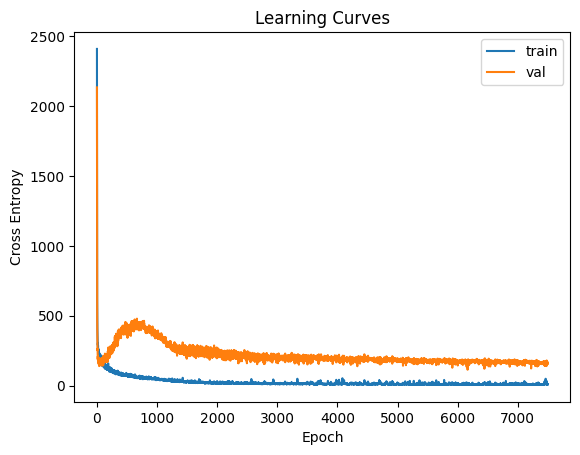

     Actual  Predicted Experiment
0     51.43  47.155464   GSE13070
1     34.20  54.401276    GSE8157
2     47.00  47.399624   GSE13070
3     39.00  33.173164   GSE47969
4     25.69  44.840752    GSE9103
..      ...        ...        ...
151   61.00  61.475159   GSE47969
152   54.15  45.646954   GSE13070
153   51.68  45.941010   GSE13070
154   46.00  49.388340   GSE48278
155   68.00  44.104515   GSE47969

[156 rows x 3 columns]


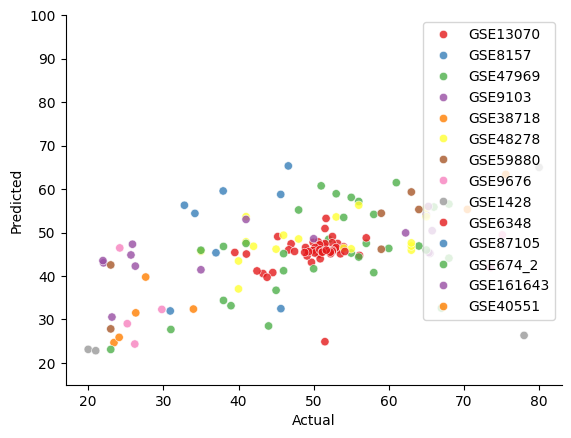

Experiment
GSE13070      50
GSE47969      29
GSE48278      21
GSE9103       12
GSE6348        7
GSE38718       6
GSE9676        6
GSE59880       6
GSE1428        4
GSE87105       4
GSE8157        4
GSE161643      3
GSE674_2       3
GSE40551       1
Name: count, dtype: int64
mae: 8.530380889696952, mse: 130.52475070509507, min: 22.828224182128906, max: 65.32213592529297
[130.5532989501953, 8.530380249023438]


In [5]:
m.plot_model(my_model.model, 'model.png', show_shapes=True)
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.print_performance(my_model.history, results, my_model.z_test)
print(error)


In [6]:
my_model.z_train[['Experiment']].value_counts()

Experiment
GSE13070      230
GSE47969       96
GSE48278       93
GSE9103        28
GSE59880       24
GSE9676        24
GSE161643      21
GSE8157        19
GSE1428        18
GSE38718       16
GSE40551       15
GSE6348        13
GSE674_2       12
GSE87105       12
Name: count, dtype: int64

In [7]:
training_data[training_data["Experiment"]=="GSE1428"]

,Sample,U48705,M87338,X51757,X69699,L36861,L13852,X55005,X79510,M21121,...,AI571298,AA149545,C18318,AI219073,AI205180,AI363375,Experiment,Sex,Age,Status
280,GSM23735,794.612813,105.563940,20.295977,208.422971,228.274952,497.665435,213.062382,78.583611,-7.519787,...,49.219001,425.586327,14.025025,11.082983,58.462852,57.151181,GSE1428,Male,20.0,NaN
281,GSM23736,-647.283588,125.560425,-166.928382,-2294.361002,-115.669167,-416.906258,-283.243545,-98.241927,-60.253478,...,49.219001,425.586327,14.025025,11.082983,58.462852,57.151181,GSE1428,Male,70.0,NaN
282,GSM23737,783.790265,15.145055,-389.478092,-1852.273805,-132.468494,-257.092300,-129.309087,-32.816478,-30.860929,...,49.219001,425.586327,14.025025,11.082983,58.462852,57.151181,GSE1428,Male,76.0,NaN
283,GSM23738,402.503572,229.889907,-268.488766,-603.150594,26.683026,-55.871999,22.856011,-100.894310,-49.879637,...,49.219001,425.586327,14.025025,11.082983,58.462852,57.151181,GSE1428,Male,80.0,NaN
284,GSM23740,37.866953,-243.070414,-325.009327,-2284.637677,-6.915628,-385.669893,7.816437,22.883566,-81.865646,...,49.219001,425.586327,14.025025,11.082983,58.462852,57.151181,GSE1428,Male,73.0,NaN
285,GSM23741,1224.184720,605.476045,-294.099645,1385.593573,189.371247,515.826112,257.296422,47.639142,-17.029141,...,49.219001,425.586327,14.025025,11.082983,58.462852,57.151181,GSE1428,Male,74.0,NaN
286,GSM23742,603.136963,134.254548,249.910757,879.980649,175.224445,136.631176,104.246644,78.583611,31.382117,...,49.219001,425.586327,14.025025,11.082983,58.462852,57.151181,GSE1428,Male,21.0,NaN
287,GSM23743,-782.149187,60.354498,209.286604,1594.320960,114.216362,359.644290,50.281115,-45.194266,-50.744124,...,49.219001,425.586327,14.025025,11.082983,58.462852,57.151181,GSE1428,Male,20.0,NaN
288,GSM23744,-517.413012,-41.366748,268.456566,-452.114938,-191.708226,18.949990,-85.075047,-75.254607,6.312001,...,49.219001,425.586327,14.025025,11.082983,58.462852,57.151181,GSE1428,Male,19.0,NaN
289,GSM23745,-380.049902,8.189757,-211.968204,-1555.388267,-42.282632,-286.875810,-392.943964,281.932980,237.994447,...,49.219001,425.586327,14.025025,11.082983,58.462852,57.151181,GSE1428,Male,80.0,NaN


In [8]:
results = m.evaluate_model(my_model.model, normalized_X_test_fs, my_model.y_test)

MAE: 8.530
Loss: 130.553
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [9]:
results["Experiment"] = my_model.z_test["Experiment"].values
results["Sample"] = my_model.z_test["Sample"].values
results["Sex"] = my_model.z_test["Sex"].values
results["Status"] = my_model.z_test["Status"].values

results["absolute_error"] = abs(results["Actual"]-results["Predicted"])
results["big_absolute_error"] = np.where(results["absolute_error"] < 5, 0, results["absolute_error"])
results

,Actual,Predicted,Experiment,Sample,Sex,Status,absolute_error,big_absolute_error
0,51.43,47.155464,GSE13070,GSM342889,Male,IRd,4.274536,0.000000
1,34.20,54.401276,GSE8157,GSM201859,Female,nPOS,20.201276,20.201276
2,47.00,47.399624,GSE13070,GSM342753,Male,IRd,0.399624,0.000000
3,39.00,33.173164,GSE47969,GSM1163761,Male,NaN,5.826836,5.826836
4,25.69,44.840752,GSE9103,GSM230421,Male,Trained,19.150752,19.150752
...,...,...,...,...,...,...,...,...
151,61.00,61.475159,GSE47969,GSM1163852,Male,NaN,0.475159,0.000000
152,54.15,45.646954,GSE13070,GSM342826,Male,IRd,8.503046,8.503046
153,51.68,45.941010,GSE13070,GSM342628,Male,IRd � TZD,5.738990,5.738990
154,46.00,49.388340,GSE48278,GSM1174129,Male,exercise group: D (Moderate aerobic exercise),3.388340,0.000000


In [10]:
results["absolute_error"].describe()

count    156.000000
mean       8.530381
std        7.624302
min        0.116173
25%        3.623578
50%        6.180445
75%       11.496900
max       51.658131
Name: absolute_error, dtype: float64

In [11]:
er.evaluate_error_experiment(results)



,sum_sq,df,F,PR(>F)
Experiment,2574.779616,13.0,4.370305,0.000004
Residual,6435.367387,142.0,NaN,NaN


In [12]:
er.evaluate_Kruskal_Wallis(results)

(37.98446311211296,
 0.0002899262881571774,
 'h statistic: 37.98446311211296 p-value: 0.0002899262881571774')

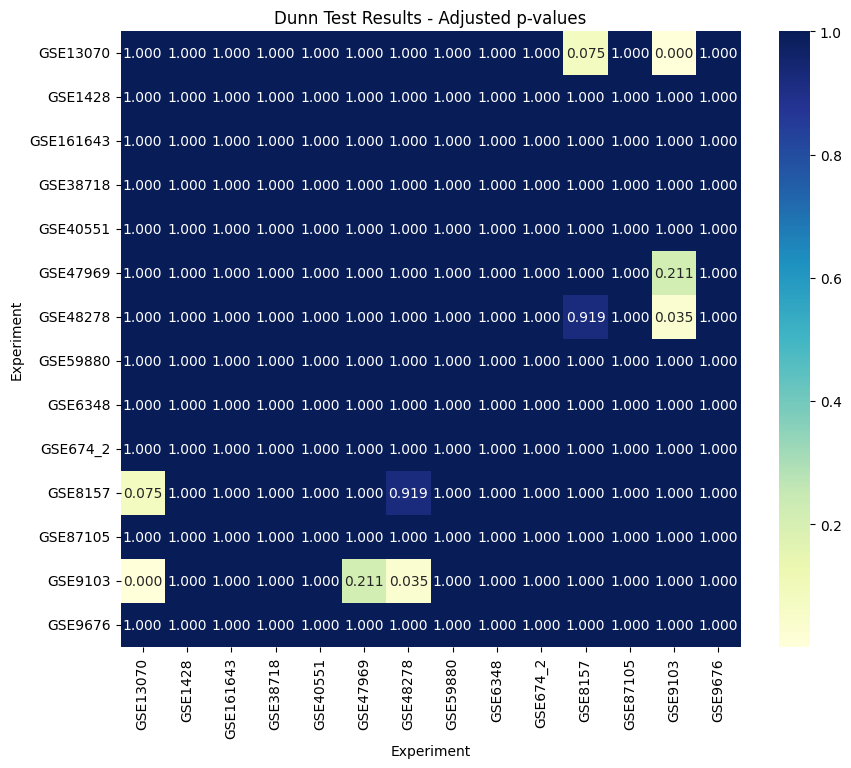

In [13]:

er.plot_Dunes_result(er.evaluate_Dunnes_test(results))

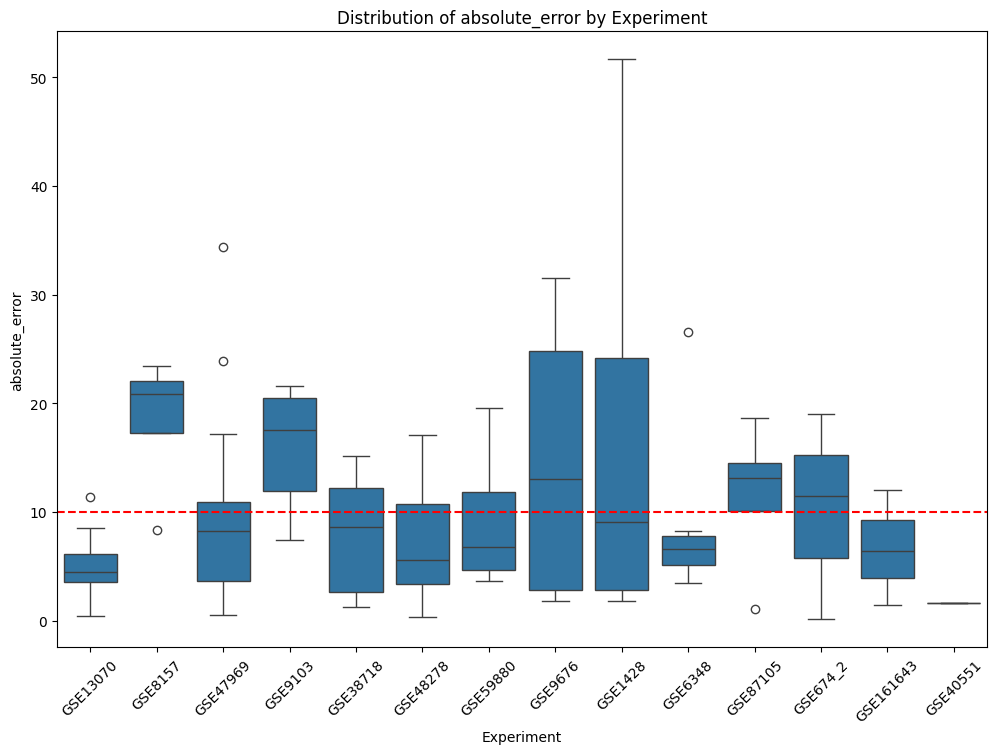

In [14]:

er.evaluate_grup_all_test(results)

In [15]:


# Assuming your DataFrame is called df
formula = 'absolute_error ~ Experiment'
model = ols(formula, data=results).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
Experiment,2574.779616,13.0,4.370305,0.000004
Residual,6435.367387,142.0,NaN,NaN


In [16]:
formula = 'absolute_error ~ Sex'
model = ols(formula, data=results).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
Sex,10.472750,1.0,0.179207,0.672646
Residual,8999.674253,154.0,NaN,NaN


In [17]:
formula = 'big_absolute_error ~ Experiment'
model = ols(formula, data=results).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
Experiment,3214.217197,13.0,4.376353,0.000003
Residual,8022.466326,142.0,NaN,NaN


In [18]:
from scipy.stats import kruskal

# Assuming your DataFrame is called df
# Group absolute_error by Experiment
experiment_groups = [group["absolute_error"] for name, group in results.groupby("Experiment")]

# Perform Kruskal-Wallis H-test
h_statistic, p_value = kruskal(*experiment_groups)

print("Kruskal-Wallis H-test:")
print("H-statistic:", h_statistic)
print("p-value:", p_value)

Kruskal-Wallis H-test:
H-statistic: 37.98446311211296
p-value: 0.0002899262881571774


In [19]:
import scikit_posthocs as sp



# Perform Dunn test as post-hoc analysis
dunn_results = sp.posthoc_dunn(results, val_col='absolute_error', group_col='Experiment', p_adjust='holm')
dunn_results

,GSE13070,GSE1428,GSE161643,GSE38718,GSE40551,GSE47969,GSE48278,GSE59880,GSE6348,GSE674_2,GSE8157,GSE87105,GSE9103,GSE9676
GSE13070,1.000000,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,0.075438,1.0,0.000040,1.0
GSE1428,1.000000,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0
GSE161643,1.000000,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0
GSE38718,1.000000,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0
GSE40551,1.000000,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0
GSE47969,1.000000,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,0.211026,1.0
GSE48278,1.000000,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,0.919472,1.0,0.034875,1.0
GSE59880,1.000000,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0
GSE6348,1.000000,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0
GSE674_2,1.000000,1.0,1.0,1.0,1.0,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0


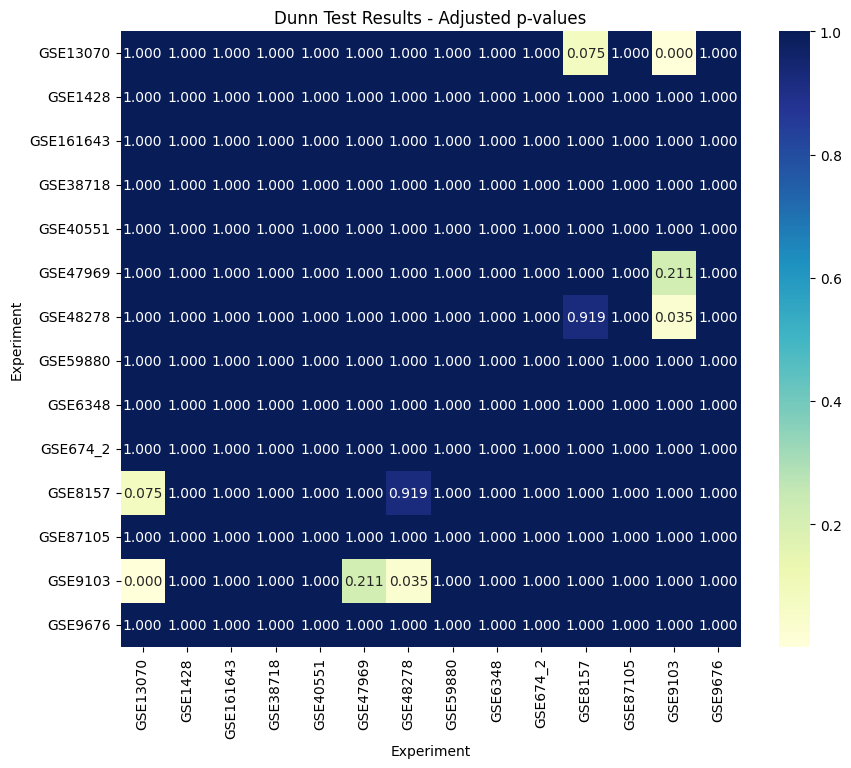

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dunn_results contains the results of the Dunn test

# Generate heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(dunn_results, annot=True, cmap="YlGnBu", fmt=".3f", cbar=True)

# Set title and labels
plt.title("Dunn Test Results - Adjusted p-values")
plt.xlabel("Experiment")
plt.ylabel("Experiment")

# Show plot
plt.show()

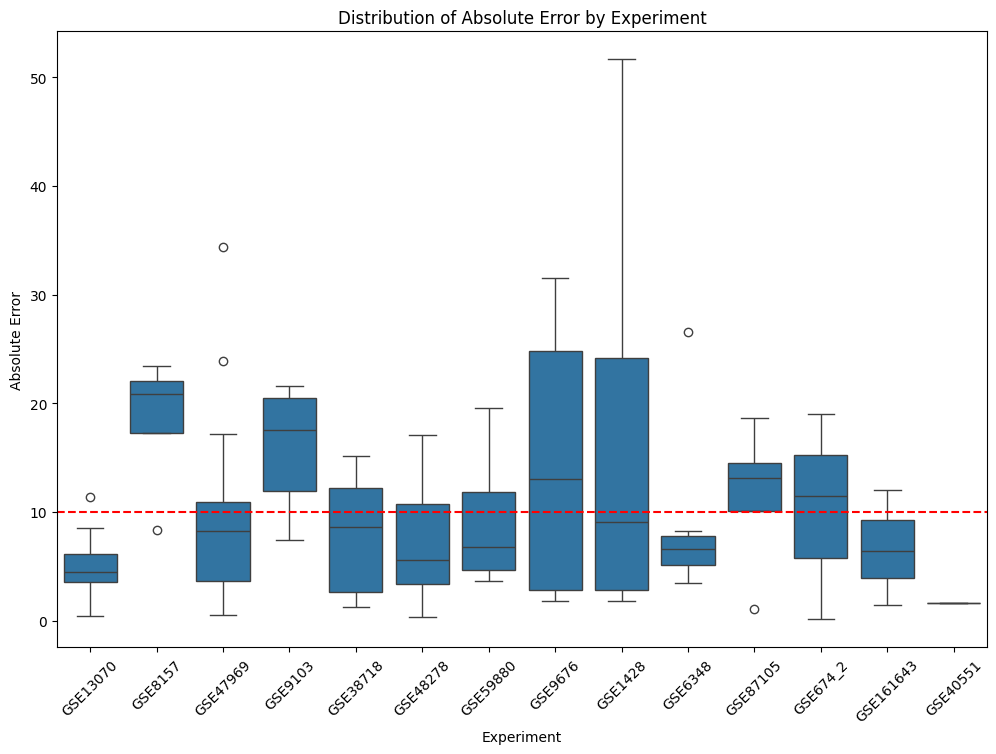

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming dunn_results contains the adjusted p-values from the Dunn test

# Generate boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(data=results, x="Experiment", y="absolute_error")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Set title and labels
plt.title("Distribution of Absolute Error by Experiment")
plt.xlabel("Experiment")
plt.ylabel("Absolute Error")
plt.axhline(y=10, color='r', linestyle='--')

# Show plot
plt.show()

In [22]:
results["Status"].unique()

array(['IRd', 'nPOS', nan, 'Trained', 'IRd � TZD',
       'exercise group: E (Aerobic + Resistance exercise)', 'NRd',
       'Sedentary', 'exercise group: A (Mild aerobic exercise)',
       'NRd � TZD', 'exercise group: F (Resistance exercise)',
       'exercise group: C (High aerobic exercise)', 'POS', 'Menopause',
       'exercise group: D (Moderate aerobic exercise)', 'RYGB', 'T2DM',
       'exercise group: B (Inactive control)',
       'obsese after 8-week training'], dtype=object)

In [ ]:
my_model.get_feature_weigths()


In [36]:
my_model.feature_importance

array([ True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True, False,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True, False,  True, False,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True])

In [37]:
final_genes = m.get_final_selected_genes(pd.DataFrame(my_model.X_train), my_model.selector, my_model.feature_importance)
weigths = [x for x in my_model.lasso.coef_ if x != 0]
df_feature_importance = pd.DataFrame({'Gene': final_genes, 'Weigth': weigths})
df_feature_importance.iloc[df_feature_importance['Weigth'].abs().argsort()[::-1]]


,Gene,Weigth
8,4529,-6.210371
38,16601,4.949995
9,5995,3.519915
5,1682,-3.351111
26,11886,2.433412
...,...,...
39,16663,0.100142
24,10129,0.067138
31,13033,0.036992
63,26830,0.022476


In [38]:
df_feature_importance.iloc[df_feature_importance['Weigth'].abs().argsort()[::-1]][:15]


,Gene,Weigth
8,4529,-6.210371
38,16601,4.949995
9,5995,3.519915
5,1682,-3.351111
26,11886,2.433412
0,28,-2.346441
58,22616,2.299379
2,86,-2.201748
25,10131,2.123161
1,77,2.096125


In [39]:
df_feature_importance.to_csv('Results/feature_importance.csv', index=False)

In [40]:
results["absoulte_error"] = abs(results["Actual"]-results["Predicted"])

In [41]:
my_model.model.save('model.keras')

     Actual  Predicted Experiment      Sample     Sex  \
1     34.20  54.401276    GSE8157   GSM201859  Female   
4     25.69  44.840752    GSE9103   GSM230421    Male   
5     64.00  46.902790   GSE47969  GSM1163857    Male   
19    63.00  45.948776   GSE48278  GSM1174098  Female   
20    22.04  43.025574    GSE9103   GSM230416    Male   
33    23.00  42.545448   GSE59880  GSM1448920    Male   
41    73.50  41.952560    GSE9676   GSM244597    Male   
46    63.00  46.885635   GSE48278  GSM1174141    Male   
62    46.63  65.322136   GSE87105  GSM2322456    Male   
68    67.00  32.620422   GSE47969  GSM1163865    Male   
71    70.46  55.325851   GSE38718   GSM948637    Male   
74    60.00  46.348984   GSE47969  GSM1163848    Male   
82    65.48  45.209812    GSE9103   GSM230406    Male   
85    37.96  59.560654    GSE8157   GSM201861  Female   
91    80.00  64.981590    GSE1428    GSM23745    Male   
99    78.00  26.341869    GSE1428    GSM23752    Male   
102   75.10  49.466148    GSE96

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/model.py:223: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results[print_label] = experiment_column


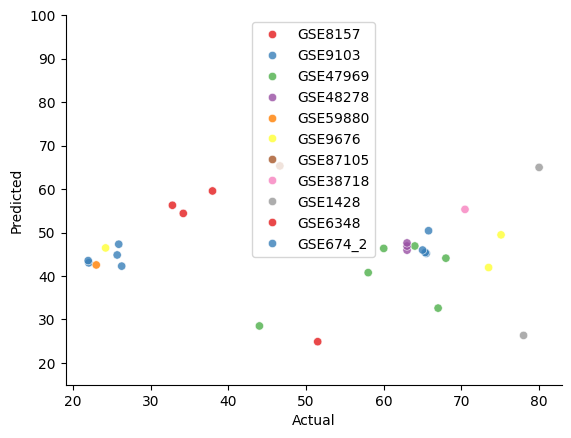

In [27]:
highest_mistake = results[results["absoulte_error"]>13.21]
m.plot_results(highest_mistake, highest_mistake, print_label="Experiment")

In [42]:
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
results["absoulte_error"] = abs(results["Actual"]-results["Predicted"])
highest_mistake = results[results["absoulte_error"]>13.21]


MAE: 8.530
Loss: 130.553
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 658us/step


In [48]:
highest_mistake["Status"]= my_model.z_test["Status"]

/tmp/ipykernel_1499522/3077346731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highest_mistake["Status"]= my_model.z_test["Status"]


     Actual  Predicted  absoulte_error    Satatus     Status
1     34.20  54.401276       20.201276        IRd        IRd
4     25.69  44.840752       19.150752        IRd        IRd
5     64.00  46.902790       17.097210        NaN        NaN
19    63.00  45.948776       17.051224        NaN        NaN
20    22.04  43.025574       20.985574        NaN        NaN
33    23.00  42.545448       19.545448        NaN        NaN
41    73.50  41.952560       31.547440        NaN        NaN
46    63.00  46.885635       16.114365        NaN        NaN
62    46.63  65.322136       18.692136        NaN        NaN
68    67.00  32.620422       34.379578        NaN        NaN
71    70.46  55.325851       15.134149        NaN        NaN
74    60.00  46.348984       13.651016        NaN        NaN
82    65.48  45.209812       20.270188        NaN        NaN
85    37.96  59.560654       21.600654  IRd � TZD  IRd � TZD
91    80.00  64.981590       15.018410        NaN        NaN
99    78.00  26.341869  

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/model.py:223: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results[print_label] = experiment_column


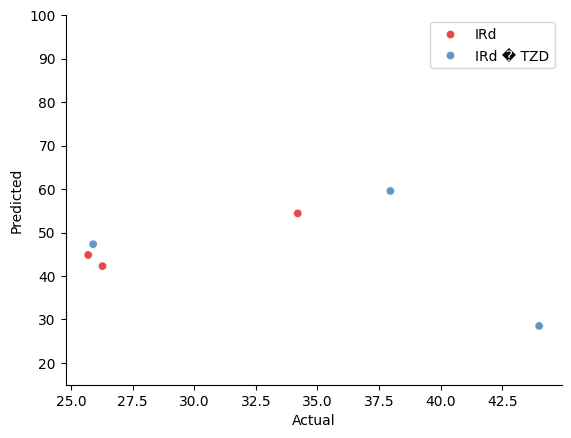

In [49]:
m.plot_results(highest_mistake, highest_mistake, print_label="Status")

In [ ]:
highest_sucess = results[results["absoulte_error"]<4]
m.plot_results(highest_sucess, highest_sucess, print_label="Experiment")

In [ ]:
m.plot_results(results=results, labels=my_model.z_test, print_label="Status")
results_extra = pd.concat([results, my_model.z_test], axis=1)

In [29]:
results

,Actual,Predicted,absoulte_error
0,51.43,47.155464,4.274536
1,34.20,54.401276,20.201276
2,47.00,47.399624,0.399624
3,39.00,33.173164,5.826836
4,25.69,44.840752,19.150752
...,...,...,...
151,61.00,61.475159,0.475159
152,54.15,45.646954,8.503046
153,51.68,45.941010,5.738990
154,46.00,49.388340,3.388340


In [ ]:
highest_mistake = results[results["absoulte_error"]>10]


In [30]:
highest_mistake[['Experiment']].value_counts()

KeyError: "None of [Index(['Experiment'], dtype='object')] are in the [columns]"

In [31]:
high_mistake_experiments = highest_mistake[['Experiment']].value_counts().index
high_mistake_experiments_a = results[['Experiment']].value_counts()[high_mistake_experiments]
high_mistake_experiments_b = highest_mistake[['Experiment']].value_counts()

KeyError: "None of [Index(['Experiment'], dtype='object')] are in the [columns]"

In [32]:
experiment_sucess=pd.DataFrame({'Total': high_mistake_experiments_a, 'Mistakes': high_mistake_experiments_b, 'Ratio': high_mistake_experiments_b/high_mistake_experiments_a})

NameError: name 'high_mistake_experiments_a' is not defined

In [33]:
experiment_sucess

NameError: name 'experiment_sucess' is not defined

his function performs a one-sided binomial test for the null hypothesis that the probability of success (in this case, making a mistake) is the same for all experiments.

In [34]:
from scipy.stats import binom, binomtest

In [35]:

# Calculate p-value for each row
experiment_sucess['p_value'] = experiment_sucess.apply(lambda row: binomtest(row['Mistakes'], row['Total']).pvalue, axis=1)


NameError: name 'experiment_sucess' is not defined

In [ ]:
experiment_sucess

In [ ]:
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.plot_results(results, my_model.z_test)

In [ ]:
m.plot_model(my_model.model, to_file='model.png', show_shapes=True)

In [ ]:
import matplotlib.pyplot as plt
#plt.hist(training_data["Age"], bins=20,orientation='vertical')
plt.bar(training_data["Experiment"].value_counts().index, training_data["Experiment"].value_counts())
plt.xticks(rotation=45)


In [ ]:
len(training_data["Experiment"].unique())

In [ ]:
plt.hist(my_model.z_train["Age"], bins=20)


In [ ]:
plt.bar(my_model.z_train["Experiment"].value_counts().index, my_model.z_train["Experiment"].value_counts())
plt.xticks(rotation=45)

In [ ]:
plt.hist(my_model.z_test["Age"], bins=20)


In [ ]:
#plt.hist(my_model.z_test["Experiment"], bins=20,orientation='horizontal')
plt.bar(my_model.z_test["Experiment"].value_counts().index, my_model.z_test["Experiment"].value_counts())
plt.xticks(rotation=45)

In [ ]:
my_model.model.summary()

I will see how was with the training data

In [ ]:
train_result, error = my_model.test(normalized_X_train, my_model.y_train)
m.print_performance(my_model.history, train_result, my_model.z_train)